<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Computer%20Vision/Object%20Detection%20Alapok%20(YOLO%2C_SSD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection Alapok (YOLO, SSD)

Ebben a notebookban az **objektum detektálás** alapjait vizsgáljuk, különös tekintettel a **YOLOv11**-re.

## Tartalomjegyzék

1. Object Detection alapok
2. Bounding Box reprezentáció
3. YOLO architektúra
4. SSD (Single Shot Detector)
5. YOLOv11 használata

## 1. Object Detection alapok

### Feladat

| Klasszifikáció | Detektálás |
|----------------|------------|
| Mi van a képen? | Mi és HOL van? |
| 1 címke/kép | N bounding box + címke |

### Megközelítések

| Típus | Példák | Sebesség |
|-------|--------|----------|
| Two-stage | R-CNN, Faster R-CNN | Lassabb, pontosabb |
| One-stage | YOLO, SSD, RetinaNet | Gyorsabb |

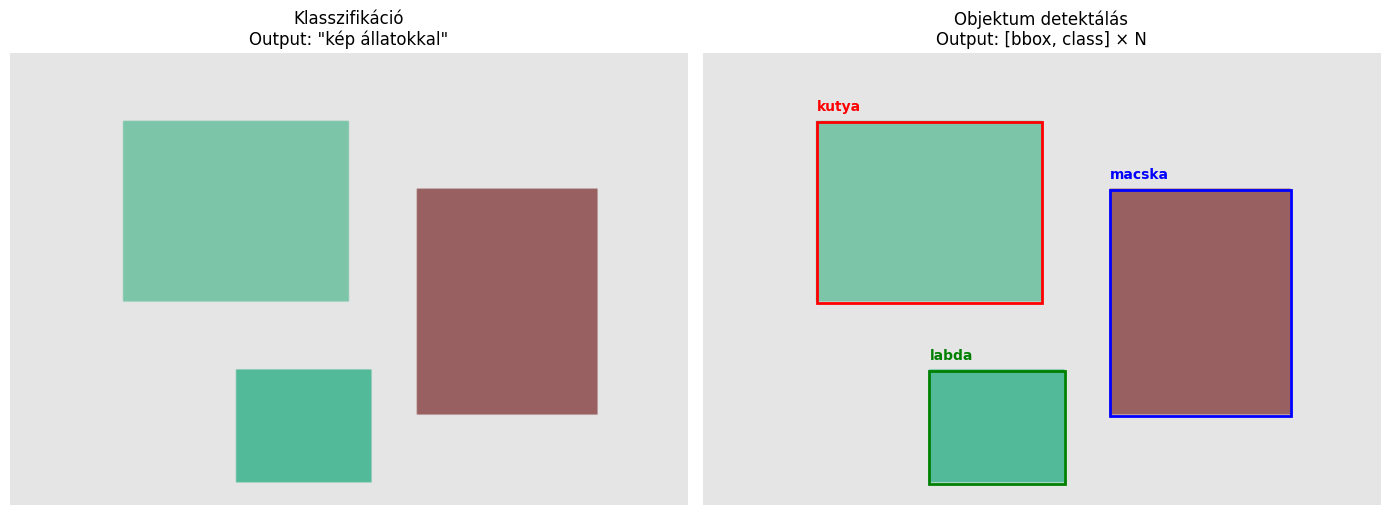

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

# Object detection vizualizáció
def visualize_detection_task():
    """Detection vs Classification."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Szintetikus kép
    img = np.ones((200, 300, 3)) * 0.9

    # Objektumok
    objects = [
        {'bbox': [50, 30, 100, 80], 'class': 'kutya', 'color': 'red'},
        {'bbox': [180, 60, 80, 100], 'class': 'macska', 'color': 'blue'},
        {'bbox': [100, 140, 60, 50], 'class': 'labda', 'color': 'green'},
    ]

    # Rajzolás
    for obj in objects:
        x, y, w, h = obj['bbox']
        img[y:y+h, x:x+w] = np.random.rand(3) * 0.5 + 0.3

    # Classification
    axes[0].imshow(img)
    axes[0].set_title('Klasszifikáció\nOutput: "kép állatokkal"', fontsize=12)
    axes[0].axis('off')

    # Detection
    axes[1].imshow(img)
    for obj in objects:
        x, y, w, h = obj['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=obj['color'], facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x, y-5, f"{obj['class']}", color=obj['color'],
                    fontsize=10, fontweight='bold')
    axes[1].set_title('Objektum detektálás\nOutput: [bbox, class] × N', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_detection_task()

## 2. Bounding Box reprezentáció

### Formátumok

| Formátum | Leírás | Példa |
|----------|--------|-------|
| xyxy | (x1, y1, x2, y2) | Bal-felső, jobb-alsó |
| xywh | (x, y, w, h) | Bal-felső + méret |
| cxcywh | (cx, cy, w, h) | Középpont + méret |

xyxy:   [50, 30, 150, 110]
xywh:   [50, 30, 100, 80]
cxcywh: [100.0, 70.0, 100, 80]


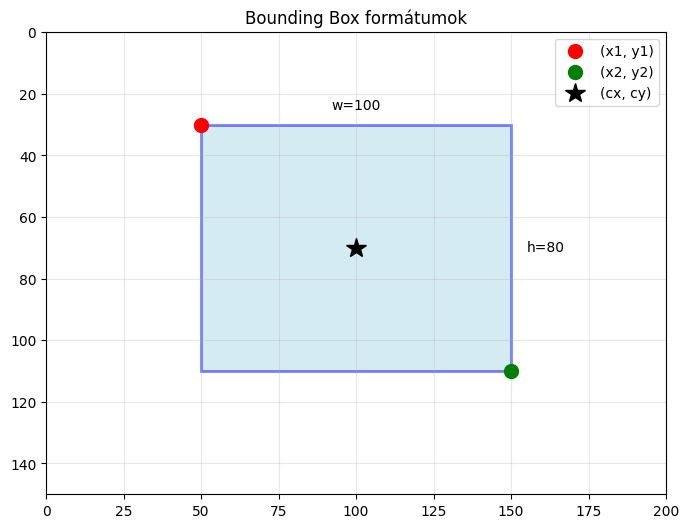

In [3]:
# Bounding box formátumok

def xyxy_to_xywh(box):
    """(x1, y1, x2, y2) -> (x, y, w, h)"""
    x1, y1, x2, y2 = box
    return [x1, y1, x2-x1, y2-y1]

def xywh_to_xyxy(box):
    """(x, y, w, h) -> (x1, y1, x2, y2)"""
    x, y, w, h = box
    return [x, y, x+w, y+h]

def xywh_to_cxcywh(box):
    """(x, y, w, h) -> (cx, cy, w, h)"""
    x, y, w, h = box
    return [x + w/2, y + h/2, w, h]

def cxcywh_to_xywh(box):
    """(cx, cy, w, h) -> (x, y, w, h)"""
    cx, cy, w, h = box
    return [cx - w/2, cy - h/2, w, h]

# Példa
xyxy = [50, 30, 150, 110]  # x1, y1, x2, y2
xywh = xyxy_to_xywh(xyxy)
cxcywh = xywh_to_cxcywh(xywh)

print(f"xyxy:   {xyxy}")
print(f"xywh:   {xywh}")
print(f"cxcywh: {cxcywh}")

# Vizualizáció
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_xlim(0, 200)
ax.set_ylim(150, 0)

# Box
x, y, w, h = xywh
rect = patches.Rectangle((x, y), w, h, linewidth=2,
                          edgecolor='blue', facecolor='lightblue', alpha=0.5)
ax.add_patch(rect)

# Annotációk
ax.plot(*xyxy[:2], 'ro', markersize=10, label='(x1, y1)')
ax.plot(*xyxy[2:], 'go', markersize=10, label='(x2, y2)')
ax.plot(cxcywh[0], cxcywh[1], 'k*', markersize=15, label='(cx, cy)')

ax.annotate(f'w={w}', xy=(x+w/2, y-5), ha='center')
ax.annotate(f'h={h}', xy=(x+w+5, y+h/2), va='center')

ax.legend()
ax.set_title('Bounding Box formátumok')
ax.grid(True, alpha=0.3)
plt.show()

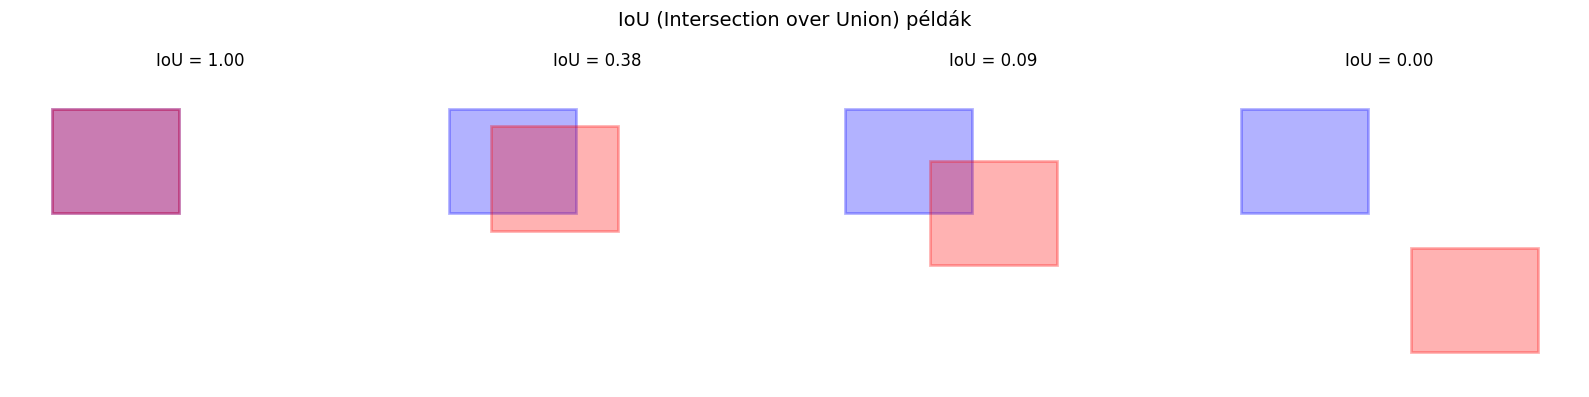

In [5]:
# IoU (Intersection over Union)

def compute_iou(box1, box2):
    """IoU számítás xyxy formátumban."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Intersection
    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    intersection = inter_w * inter_h

    # Union
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

# Példa különböző IoU értékekkel
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

box1 = [20, 20, 80, 80]  # Fix box
boxes2 = [
    [20, 20, 80, 80],    # Tökéletes egyezés
    [40, 30, 100, 90],   # Részleges átfedés
    [60, 50, 120, 110],  # Kis átfedés
    [100, 100, 160, 160] # Nincs átfedés
]

for ax, box2 in zip(axes, boxes2):
    ax.set_xlim(0, 180)
    ax.set_ylim(180, 0)

    # Box 1 (kék)
    rect1 = patches.Rectangle((box1[0], box1[1]),
                               box1[2]-box1[0], box1[3]-box1[1],
                               linewidth=2, edgecolor='blue',
                               facecolor='blue', alpha=0.3)
    ax.add_patch(rect1)

    # Box 2 (piros)
    rect2 = patches.Rectangle((box2[0], box2[1]),
                               box2[2]-box2[0], box2[3]-box2[1],
                               linewidth=2, edgecolor='red',
                               facecolor='red', alpha=0.3)
    ax.add_patch(rect2)

    iou = compute_iou(box1, box2)
    ax.set_title(f'IoU = {iou:.2f}')
    ax.axis('off')

plt.suptitle('IoU (Intersection over Union) példák', fontsize=14)
plt.tight_layout()
plt.show()

## 3. YOLO architektúra

### YOLO koncepció

"You Only Look Once" - egyetlen forward pass-ban detektál.

### Grid-based detection

1. Kép felosztása S×S gridre
2. Minden grid cell B bounding box-ot prediktál
3. Output: S × S × (B × 5 + C)
   - 5 = (x, y, w, h, confidence)
   - C = osztályok száma

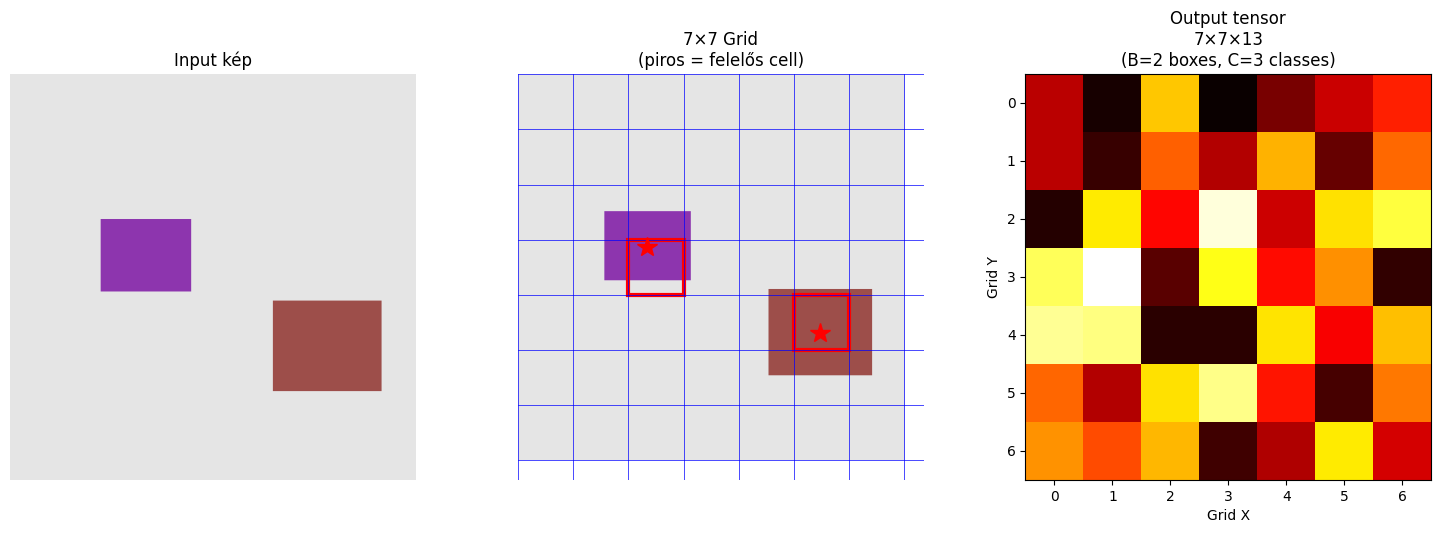

Output tensor shape: (7, 7, 13)
  - 2 × 5 = 10 (box coords + confidence)
  - 3 class probabilities


In [6]:
# YOLO grid vizualizáció

def visualize_yolo_grid(S=7):
    """YOLO grid-based detection vizualizáció."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    img_size = 448
    cell_size = img_size // S

    # Szintetikus kép objektumokkal
    img = np.ones((img_size, img_size, 3)) * 0.9

    objects = [
        {'center': (150, 200), 'size': (100, 80), 'class': 'A'},
        {'center': (350, 300), 'size': (120, 100), 'class': 'B'},
    ]

    for obj in objects:
        cx, cy = obj['center']
        w, h = obj['size']
        img[cy-h//2:cy+h//2, cx-w//2:cx+w//2] = np.random.rand(3) * 0.5 + 0.2

    # 1. Eredeti kép
    axes[0].imshow(img)
    axes[0].set_title('Input kép', fontsize=12)
    axes[0].axis('off')

    # 2. Grid felosztás
    axes[1].imshow(img)
    for i in range(S+1):
        axes[1].axhline(i * cell_size, color='blue', linewidth=0.5)
        axes[1].axvline(i * cell_size, color='blue', linewidth=0.5)

    # Objektum középpontok
    for obj in objects:
        cx, cy = obj['center']
        axes[1].plot(cx, cy, 'r*', markersize=15)

        # Melyik cell?
        cell_x = int(cx // cell_size)
        cell_y = int(cy // cell_size)
        rect = patches.Rectangle((cell_x*cell_size, cell_y*cell_size),
                                  cell_size, cell_size,
                                  linewidth=3, edgecolor='red', facecolor='none')
        axes[1].add_patch(rect)

    axes[1].set_title(f'{S}×{S} Grid\n(piros = felelős cell)', fontsize=12)
    axes[1].axis('off')

    # 3. Output tensor
    B = 2  # boxes per cell
    C = 3  # classes
    output_channels = B * 5 + C

    output = np.random.rand(S, S, output_channels)

    # Egy channel megjelenítése
    axes[2].imshow(output[:, :, 4], cmap='hot')  # Confidence
    axes[2].set_title(f'Output tensor\n{S}×{S}×{output_channels}\n(B={B} boxes, C={C} classes)', fontsize=12)
    axes[2].set_xlabel('Grid X')
    axes[2].set_ylabel('Grid Y')

    plt.tight_layout()
    plt.show()

    print(f"Output tensor shape: ({S}, {S}, {output_channels})")
    print(f"  - {B} × 5 = {B*5} (box coords + confidence)")
    print(f"  - {C} class probabilities")

visualize_yolo_grid(S=7)

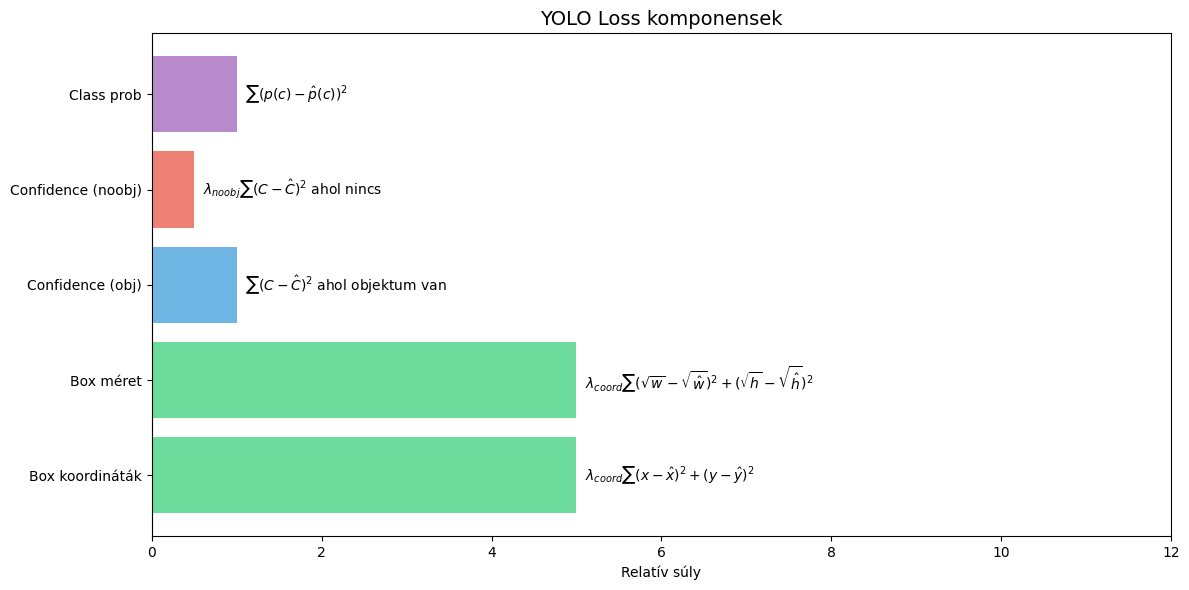

In [7]:
# YOLO Loss komponensek

def visualize_yolo_loss():
    """YOLO loss komponensek."""

    components = {
        'Box koordináták': r'$\lambda_{coord} \sum (x - \hat{x})^2 + (y - \hat{y})^2$',
        'Box méret': r'$\lambda_{coord} \sum (\sqrt{w} - \sqrt{\hat{w}})^2 + (\sqrt{h} - \sqrt{\hat{h}})^2$',
        'Confidence (obj)': r'$\sum (C - \hat{C})^2$ ahol objektum van',
        'Confidence (noobj)': r'$\lambda_{noobj} \sum (C - \hat{C})^2$ ahol nincs',
        'Class prob': r'$\sum (p(c) - \hat{p}(c))^2$',
    }

    fig, ax = plt.subplots(figsize=(12, 6))

    y_pos = np.arange(len(components))
    weights = [5, 5, 1, 0.5, 1]  # Relatív súlyok
    colors = ['#2ecc71', '#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

    bars = ax.barh(y_pos, weights, color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(list(components.keys()))
    ax.set_xlabel('Relatív súly')
    ax.set_title('YOLO Loss komponensek', fontsize=14)

    # Képletek
    for i, (name, formula) in enumerate(components.items()):
        ax.text(weights[i] + 0.1, i, formula, va='center', fontsize=10)

    ax.set_xlim(0, 12)
    plt.tight_layout()
    plt.show()

visualize_yolo_loss()

## 4. SSD (Single Shot Detector)

### SSD vs YOLO

| Tulajdonság | YOLO | SSD |
|-------------|------|-----|
| Multi-scale | Nem (eredeti) | Igen |
| Anchor boxes | Fix grid | Pretrained anchors |
| Sebesség | Gyors | Gyors |

### Multi-scale feature maps

SSD különböző felbontású feature map-ekből detektál.

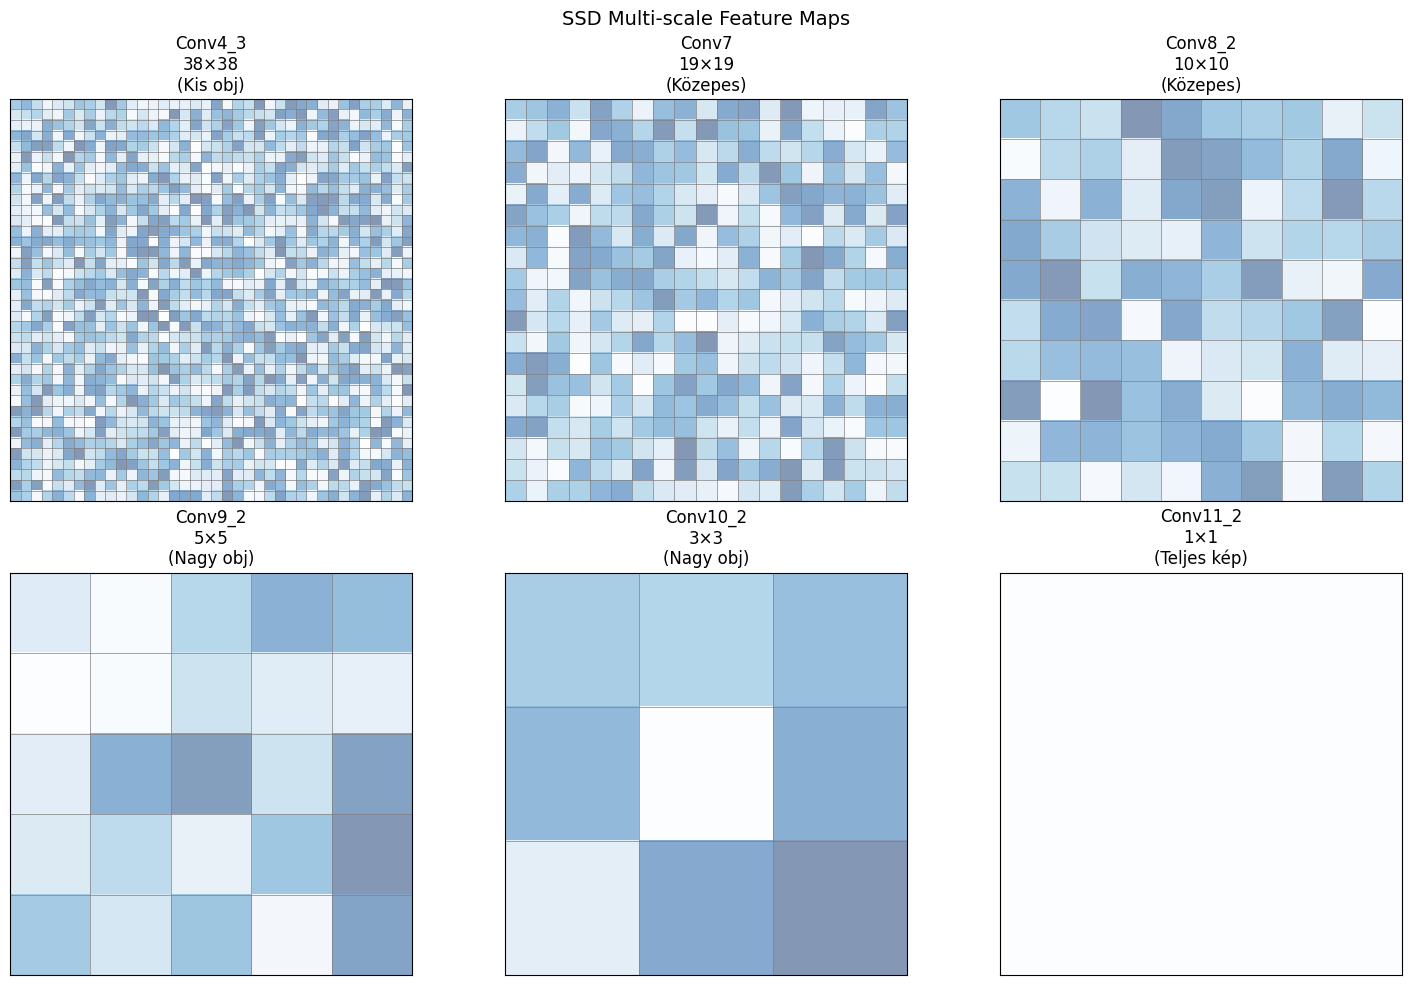

Összes anchor pozíció:
  Conv4_3    38×38 × 6 =  8664
  Conv7      19×19 × 6 =  2166
  Conv8_2    10×10 × 6 =   600
  Conv9_2     5× 5 × 6 =   150
  Conv10_2    3× 3 × 4 =    36
  Conv11_2    1× 1 × 4 =     4
  Összesen   11620


In [8]:
# SSD multi-scale detection

def visualize_ssd_multiscale():
    """SSD multi-scale feature maps."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Feature map méretek (SSD300)
    feature_maps = [
        {'size': 38, 'name': 'Conv4_3', 'scale': 'Kis obj'},
        {'size': 19, 'name': 'Conv7', 'scale': 'Közepes'},
        {'size': 10, 'name': 'Conv8_2', 'scale': 'Közepes'},
        {'size': 5, 'name': 'Conv9_2', 'scale': 'Nagy obj'},
        {'size': 3, 'name': 'Conv10_2', 'scale': 'Nagy obj'},
        {'size': 1, 'name': 'Conv11_2', 'scale': 'Teljes kép'},
    ]

    for ax, fm in zip(axes.ravel(), feature_maps):
        # Grid vizualizáció
        grid = np.random.rand(fm['size'], fm['size'])
        ax.imshow(grid, cmap='Blues', alpha=0.5)

        # Grid vonalak
        for i in range(fm['size'] + 1):
            ax.axhline(i - 0.5, color='gray', linewidth=0.5)
            ax.axvline(i - 0.5, color='gray', linewidth=0.5)

        ax.set_title(f"{fm['name']}\n{fm['size']}×{fm['size']}\n({fm['scale']})")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle('SSD Multi-scale Feature Maps', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Anchor számítás
    print("Összes anchor pozíció:")
    total = 0
    for fm in feature_maps:
        anchors_per_cell = 6 if fm['size'] > 3 else 4
        count = fm['size'] ** 2 * anchors_per_cell
        total += count
        print(f"  {fm['name']:10} {fm['size']:2}×{fm['size']:2} × {anchors_per_cell} = {count:5}")
    print(f"  {'Összesen':10} {total}")

visualize_ssd_multiscale()

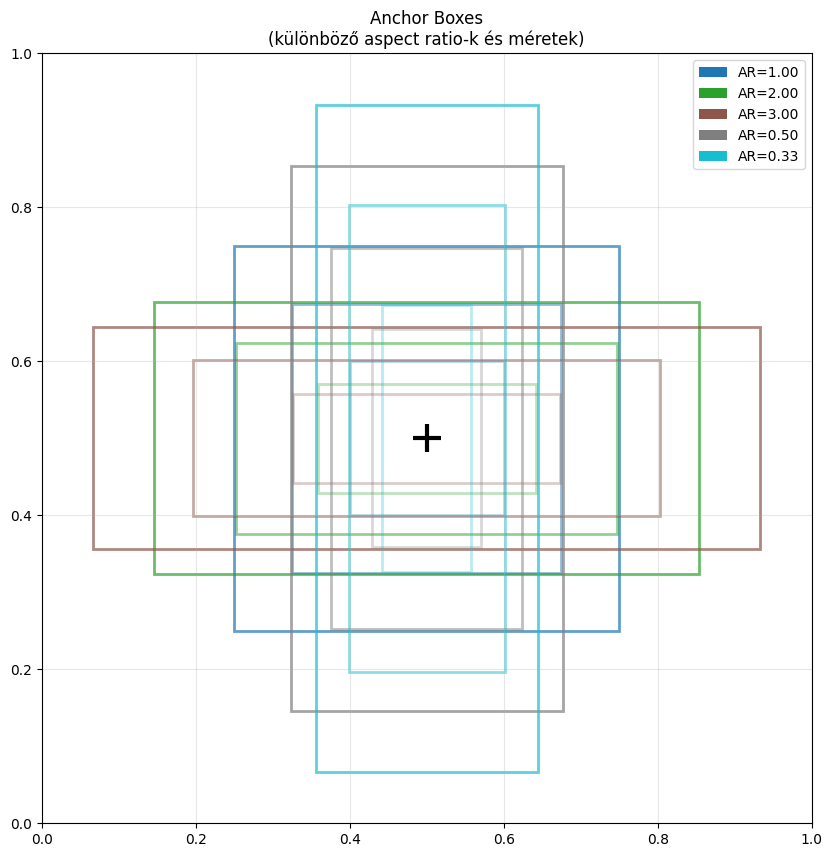

In [9]:
# Anchor boxes vizualizáció

def visualize_anchor_boxes():
    """Anchor boxes különböző aspect ratio-kkal."""
    fig, ax = plt.subplots(figsize=(10, 10))

    # Aspect ratios
    aspect_ratios = [1, 2, 3, 1/2, 1/3]
    scales = [0.2, 0.35, 0.5]

    center = (0.5, 0.5)
    colors = plt.cm.tab10(np.linspace(0, 1, len(aspect_ratios)))

    for i, ar in enumerate(aspect_ratios):
        for j, scale in enumerate(scales):
            w = scale * np.sqrt(ar)
            h = scale / np.sqrt(ar)

            x = center[0] - w/2
            y = center[1] - h/2

            alpha = 0.3 + 0.2 * j
            rect = patches.Rectangle((x, y), w, h,
                                      linewidth=2,
                                      edgecolor=colors[i],
                                      facecolor='none',
                                      alpha=alpha)
            ax.add_patch(rect)

    # Center
    ax.plot(*center, 'k+', markersize=20, mew=3)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title('Anchor Boxes\n(különböző aspect ratio-k és méretek)')
    ax.grid(True, alpha=0.3)

    # Legend
    legend_elements = [patches.Patch(facecolor=colors[i],
                                     label=f'AR={ar:.2f}')
                       for i, ar in enumerate(aspect_ratios)]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.show()

visualize_anchor_boxes()

## 5. YOLOv11 használata

### Ultralytics YOLOv11

A legújabb YOLO verzió az Ultralytics-től.

### Telepítés

```bash
pip install ultralytics
```

In [10]:
# YOLOv11 használata (ha telepítve van)

try:
    from ultralytics import YOLO

    # Modell betöltése
    print("YOLOv11 modellek:")
    print("  - yolo11n.pt (nano)    - leggyorsabb")
    print("  - yolo11s.pt (small)   - gyors")
    print("  - yolo11m.pt (medium)  - kiegyensúlyozott")
    print("  - yolo11l.pt (large)   - pontos")
    print("  - yolo11x.pt (extra)   - legpontosabb")

    # Nano modell betöltése (legkisebb)
    model = YOLO('yolo11n.pt')
    print(f"\nModell betöltve: {model.model}")

    YOLO_AVAILABLE = True

except ImportError:
    print("Ultralytics nincs telepítve.")
    print("Telepítés: pip install ultralytics")
    YOLO_AVAILABLE = False

YOLOv11 modellek:
  - yolo11n.pt (nano)    - leggyorsabb
  - yolo11s.pt (small)   - gyors
  - yolo11m.pt (medium)  - kiegyensúlyozott
  - yolo11l.pt (large)   - pontos
  - yolo11x.pt (extra)   - legpontosabb

Modell betöltve: DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(

In [11]:
# YOLOv11 inference példa

if YOLO_AVAILABLE:
    # Szintetikus teszt kép
    test_img = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

    # Inference
    results = model(test_img, verbose=False)

    print("YOLOv11 inference:")
    print(f"  Input: {test_img.shape}")
    print(f"  Detektált objektumok: {len(results[0].boxes)}")

    # Eredmények
    for r in results:
        boxes = r.boxes
        if len(boxes) > 0:
            print(f"\n  Bounding boxes shape: {boxes.xyxy.shape}")
            print(f"  Confidence scores: {boxes.conf[:5]}")
            print(f"  Class IDs: {boxes.cls[:5]}")
else:
    print("YOLOv11 nem elérhető - szimulált eredmény:")
    print("  Bounding boxes: [[100, 150, 300, 400], [400, 200, 550, 450]]")
    print("  Classes: ['person', 'car']")
    print("  Confidences: [0.92, 0.87]")

YOLOv11 inference:
  Input: (640, 640, 3)
  Detektált objektumok: 0


In [12]:
# YOLOv11 API összefoglaló

yolo_api = """
# ============================================
# YOLOv11 Ultralytics API
# ============================================

from ultralytics import YOLO

# 1. MODELL BETÖLTÉSE
# -------------------
model = YOLO('yolo11n.pt')      # Pretrained nano
model = YOLO('yolo11s.pt')      # Pretrained small
model = YOLO('path/to/best.pt') # Custom trained

# 2. INFERENCE
# ------------
results = model('image.jpg')           # Egy kép
results = model(['img1.jpg', 'img2.jpg'])  # Több kép
results = model('video.mp4')           # Videó
results = model(0)                     # Webcam

# Inference opciók
results = model(
    'image.jpg',
    conf=0.25,      # Confidence threshold
    iou=0.45,       # NMS IoU threshold
    classes=[0, 1], # Csak bizonyos osztályok
    save=True,      # Mentés
    show=True,      # Megjelenítés
)

# 3. EREDMÉNYEK FELDOLGOZÁSA
# --------------------------
for r in results:
    boxes = r.boxes          # Bounding boxes
    boxes.xyxy               # (x1, y1, x2, y2)
    boxes.xywh               # (x, y, w, h)
    boxes.conf               # Confidence scores
    boxes.cls                # Class IDs

    # Rajzolt kép
    annotated = r.plot()

# 4. TRAINING
# -----------
model = YOLO('yolo11n.pt')
results = model.train(
    data='coco.yaml',   # Dataset config
    epochs=100,
    imgsz=640,
    batch=16,
)

# 5. VALIDATION
# -------------
metrics = model.val()
print(metrics.box.map)    # mAP@0.5:0.95
print(metrics.box.map50)  # mAP@0.5

# 6. EXPORT
# ---------
model.export(format='onnx')   # ONNX
model.export(format='torchscript')  # TorchScript
model.export(format='tflite') # TensorFlow Lite
"""

print(yolo_api)


# ============================================
# YOLOv11 Ultralytics API
# ============================================

from ultralytics import YOLO

# 1. MODELL BETÖLTÉSE
# -------------------
model = YOLO('yolo11n.pt')      # Pretrained nano
model = YOLO('yolo11s.pt')      # Pretrained small
model = YOLO('path/to/best.pt') # Custom trained

# 2. INFERENCE
# ------------
results = model('image.jpg')           # Egy kép
results = model(['img1.jpg', 'img2.jpg'])  # Több kép
results = model('video.mp4')           # Videó
results = model(0)                     # Webcam

# Inference opciók
results = model(
    'image.jpg',
    conf=0.25,      # Confidence threshold
    iou=0.45,       # NMS IoU threshold
    classes=[0, 1], # Csak bizonyos osztályok
    save=True,      # Mentés
    show=True,      # Megjelenítés
)

# 3. EREDMÉNYEK FELDOLGOZÁSA
# --------------------------
for r in results:
    boxes = r.boxes          # Bounding boxes
    boxes.xyxy               # (x1, y1, x2, y2)
    b

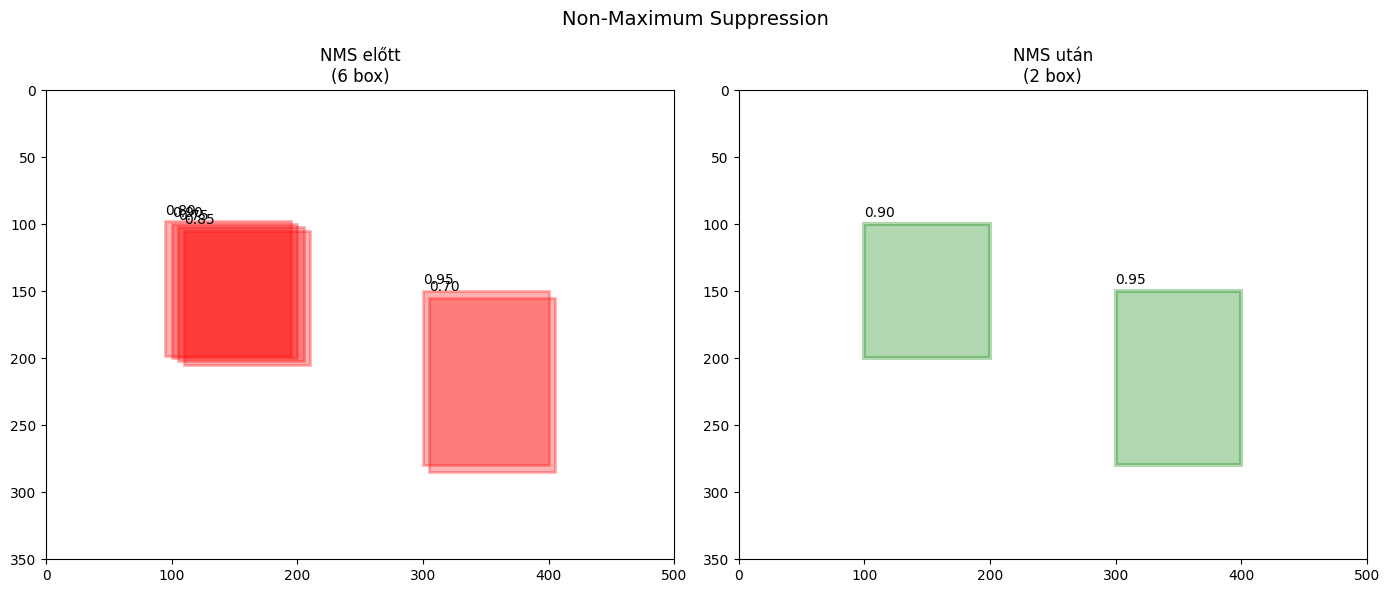

In [14]:
# Non-Maximum Suppression (NMS)

def nms(boxes, scores, iou_threshold=0.5):
    """Non-Maximum Suppression implementáció."""
    # Rendezés confidence szerint
    order = scores.argsort()[::-1]

    keep = []

    while len(order) > 0:
        # Legjobb box megtartása
        i = order[0]
        keep.append(i)

        if len(order) == 1:
            break

        # IoU számítás a többivel
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])

        # Túl nagy átfedésűek eltávolítása
        mask = ious < iou_threshold
        order = order[1:][mask]

    return keep

# NMS vizualizáció
def visualize_nms():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Sok átfedő box
    boxes = np.array([
        [100, 100, 200, 200],
        [110, 105, 210, 205],
        [95, 98, 195, 198],
        [105, 102, 205, 202],
        [300, 150, 400, 280],
        [305, 155, 405, 285],
    ])
    scores = np.array([0.9, 0.85, 0.8, 0.75, 0.95, 0.7])

    # NMS előtt
    axes[0].set_xlim(0, 500)
    axes[0].set_ylim(350, 0)

    for i, (box, score) in enumerate(zip(boxes, scores)):
        rect = patches.Rectangle((box[0], box[1]),
                                  box[2]-box[0], box[3]-box[1],
                                  linewidth=2, edgecolor='red',
                                  facecolor='red', alpha=0.3)
        axes[0].add_patch(rect)
        axes[0].text(box[0], box[1]-5, f'{score:.2f}', fontsize=10)

    axes[0].set_title(f'NMS előtt\n({len(boxes)} box)')

    # NMS után
    keep = nms(boxes, scores, iou_threshold=0.5)

    axes[1].set_xlim(0, 500)
    axes[1].set_ylim(350, 0)

    for i in keep:
        box = boxes[i]
        rect = patches.Rectangle((box[0], box[1]),
                                  box[2]-box[0], box[3]-box[1],
                                  linewidth=3, edgecolor='green',
                                  facecolor='green', alpha=0.3)
        axes[1].add_patch(rect)
        axes[1].text(box[0], box[1]-5, f'{scores[i]:.2f}', fontsize=10)

    axes[1].set_title(f'NMS után\n({len(keep)} box)')

    plt.suptitle('Non-Maximum Suppression', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_nms()

## Összefoglalás

### Object Detection módszerek

| Módszer | Típus | Sebesség | Pontosság |
|---------|-------|----------|----------|
| YOLO | One-stage | Nagyon gyors | Jó |
| SSD | One-stage | Gyors | Jó |
| Faster R-CNN | Two-stage | Lassabb | Nagyon jó |

### YOLO evolúció

```
YOLOv1 → v2 → v3 → v4 → v5 → v7 → v8 → v9 → v10 → v11
```

### YOLOv11 használat

```python
from ultralytics import YOLO

# Inference
model = YOLO('yolo11n.pt')
results = model('image.jpg')

# Training
model.train(data='dataset.yaml', epochs=100)
```

### Metrikák

| Metrika | Leírás |
|---------|--------|
| mAP | Mean Average Precision |
| IoU | Intersection over Union |
| FPS | Frames per second |